# Markowitz Mean-Variance Optimizer

Starting from market data over a given time window and an initial universe of assets, this project screens the best **n** names and builds the **Efficient Frontier**, the **Minimum-Variance Portfolio (MVP)** and the **Tangency Portfolio (TGP)**, with full graphical output.

## Output
`TgP_weights.csv` — the Tangency Portfolio weights, exported automatically to the VaR–ES and Factor Model companion projects.

## Pipeline
`markowitz`, `var-cvar` and `factor-models` form a **single pipeline**: the Markowitz module produces the Tangency Portfolio weights, which are then consumed as input by the VaR–ES and Factor Model modules.

## 1. Setup & parameters

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
import os
import matplotlib.pyplot as plt

# Time window
start="2016-03-31" 
end="2026-03-31"

rf=0.04

n=20
NaN_treshold=0.05
drawdown_treshold=-0.6
vol_treshold=0.5
verbose=True

## 2. Data sourcing

We evaluate the model on a deliberately **diversified universe**: names drawn from different sectors, asset classes and geographical regions. After defining the ticker list, we download the corresponding price history over the chosen window with `get_prices`, and we then derive the **daily log-returns** of each asset with `get_returns`.

In [2]:
# Ticker universe
tickers = ["AAPL","MSFT", "GOOGL", "NVDA", "META", "AMZN",
        "JPM", "GS", "BAC", "BLK", 
        "JNJ", "UNH", "PFE", "ABBV",
        "XOM", "CVX", "BP", "SHEL",
        "PG", "KO", "MCD", "NKE",
        "CAT", "HON", "GE",
        "ASML", "SAP", "MC.PA", "NESN.SW", "SIE.DE",
        "GLD", "SLV", "USO",
        "TLT", "BND", "HYG",
        "VNQ", "PLD",
        "NEE", "DUK"]

def get_prices(tickers: list, start: str, end: str) -> pd.DataFrame:
    """Download adjusted close prices for a list of tickers over the given time window."""
    data = yf.download(tickers, start=start, end=end)["Close"]
    return data

def get_returns(data: pd.DataFrame) -> pd.DataFrame:
    """Compute daily log-returns from a price DataFrame, dropping rows with any NaN."""
    rend = np.log(data/data.shift(1)).dropna()
    return rend

In [3]:
prices = get_prices(tickers=tickers, start=start, end=end)
prices.shape

[*********************100%***********************]  40 of 40 completed


(2584, 40)

In [4]:
prices.head()

Ticker,AAPL,ABBV,AMZN,ASML,BAC,BLK,BND,BP,CAT,CVX,...,PLD,SAP,SHEL,SIE.DE,SLV,TLT,UNH,USO,VNQ,XOM
2016-03-31,24.661386,37.468643,29.681999,90.472771,10.783196,264.390167,61.297199,16.743267,60.400497,61.806156,...,33.225498,67.623466,29.536263,61.934666,14.68,98.218407,109.418991,77.599998,56.360321,53.705700
2016-04-01,24.887659,37.665436,29.924999,90.634979,10.815102,265.911713,61.366199,16.404860,60.597790,61.067589,...,33.556400,67.043282,29.048563,60.378819,14.34,98.474617,110.284828,74.639999,56.286346,53.300945
2016-04-04,25.143345,38.839600,29.659500,91.590240,10.775220,262.798645,61.366199,16.410406,59.753429,60.529884,...,33.383419,66.883507,29.103432,60.797691,14.20,98.534897,109.919830,72.639999,56.205624,53.429432
2016-04-05,24.846930,38.400112,29.306999,89.688698,10.519997,259.910736,61.477444,16.049791,59.374638,60.037491,...,33.180374,65.462418,28.481621,59.295048,14.42,99.612473,107.840103,73.040001,55.835724,52.819077
2016-04-06,25.107134,39.285656,30.104000,91.112633,10.583802,261.774017,61.447765,16.255062,59.358845,61.443359,...,33.127720,66.589180,29.060753,59.727219,14.34,98.889053,108.680496,76.800003,55.970238,53.525822


In [5]:
prices.isna().sum()

Ticker
AAPL       70
ABBV       70
AMZN       70
ASML       70
BAC        70
BLK        70
BND        70
BP         70
CAT        70
CVX        70
DUK        70
GE         70
GLD        70
GOOGL      70
GS         70
HON        70
HYG        70
JNJ        70
JPM        70
KO         70
MC.PA      22
MCD        70
META       70
MSFT       70
NEE        70
NESN.SW    71
NKE        70
NVDA       70
PFE        70
PG         70
PLD        70
SAP        70
SHEL       70
SIE.DE     42
SLV        70
TLT        70
UNH        70
USO        70
VNQ        70
XOM        70
dtype: int64

The price matrix shows a recurring pattern of missing values. Every ticker traded on the **US market** has **70 missing days** over the 10-year window — roughly **7 per year**. These are the days on which the European exchanges are open while the US market is closed for holidays (e.g. Martin Luther King Day, Presidents' Day, Memorial Day, Independence Day, Labor Day, Thanksgiving). Symmetrically, the European names (e.g. `MC.PA`) show 22 missing days, corresponding to local holidays. On every other day the two markets are aligned.

The gaps therefore reflect **mismatched trading calendars across exchanges**, not corrupted data. When estimating the correlation and variance–covariance matrices we have two options: restrict the sample to the **intersection** of available dates (preferable when the excluded days are few, since it keeps all series strictly comparable), or apply a fill methodology to recover the missing observations.

In [6]:
returns = get_returns(prices)
returns.shape

(2314, 40)

The `get_returns` function follows the **intersection** approach: aligning all series on their common trading days removes 270 observations, about **10%** of the sample (each missing price invalidates the return on both the affected day and the following one, which is why the loss exceeds the raw count of missing prices). We accept this trade-off, as it yields fully comparable return series and therefore coherent covariance estimates.

In [7]:
returns.head()

Ticker,AAPL,ABBV,AMZN,ASML,BAC,BLK,BND,BP,CAT,CVX,...,PLD,SAP,SHEL,SIE.DE,SLV,TLT,UNH,USO,VNQ,XOM
2016-04-01,0.009133,0.005238,0.008153,0.001791,0.002954,0.005738,0.001125,-0.020419,0.003261,-0.012022,...,0.009910,-0.008617,-0.016650,-0.025442,-0.023433,0.002605,0.007882,-0.038891,-0.001313,-0.007565
2016-04-04,0.010221,0.030697,-0.008912,0.010484,-0.003694,-0.011776,0.000000,0.000338,-0.014032,-0.008844,...,-0.005168,-0.002386,0.001887,0.006913,-0.009811,0.000612,-0.003315,-0.027161,-0.001435,0.002408
2016-04-05,-0.011859,-0.011380,-0.011956,-0.020980,-0.023971,-0.011050,0.001811,-0.022220,-0.006359,-0.008168,...,-0.006101,-0.021476,-0.021597,-0.025026,0.015374,0.010877,-0.019102,0.005492,-0.006603,-0.011489
2016-04-06,0.010418,0.022799,0.026832,0.015752,0.006047,0.007143,-0.000483,0.012709,-0.000266,0.023147,...,-0.001588,0.017066,0.020130,0.007262,-0.005563,-0.007289,0.007763,0.050197,0.002406,0.013292
2016-04-07,-0.022051,-0.009900,-0.017847,-0.010040,-0.032162,-0.026536,0.003255,-0.005819,-0.014058,-0.000527,...,-0.009122,-0.024544,-0.008849,-0.019673,0.009716,0.012269,-0.009102,-0.009419,-0.006268,-0.011347


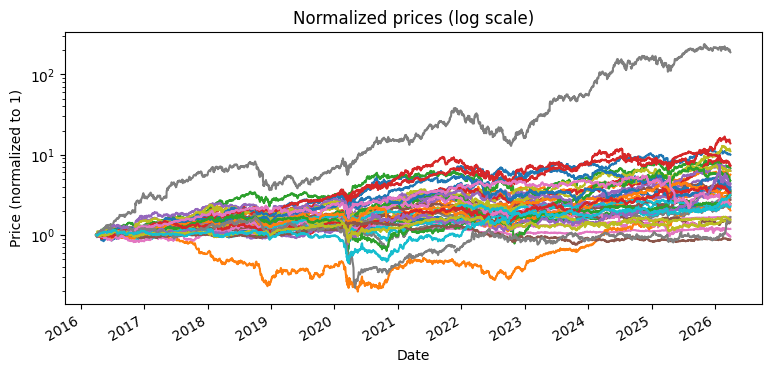

In [8]:
prices_norm = prices / prices.iloc[0]
fig, ax = plt.subplots(figsize=(9, 4))
prices_norm.plot(ax=ax, logy=True, legend=False)
ax.set_title("Normalized prices (log scale)")
ax.set_xlabel("Date")
ax.set_ylabel("Price (normalized to 1)")
plt.show()

The normalized price paths confirm a broadly **positive trend** across the universe. The **technology sector leads** — NVIDIA in particular, whose exponential growth motivates the **logarithmic y-axis**: on a log scale, equal vertical moves represent equal percentage changes, so growth rates become comparable across assets regardless of their absolute level. Overall the universe is **heterogeneous**, spanning the strongly trending tech names and the defensive assets that stay close to their starting value.

## 3. Screening

From the diversified universe, we now select a subset of **n** assets through a two-stage screening process. First, we apply data-quality and risk filters: names with excessive missing data are dropped, the remaining gaps are filled for the surviving series, and assets with excessive volatility or drawdown are removed. On this universe, no asset is removed at the missing-data stage — the filter is kept as a safeguard, but every ticker is already clean enough to pass. Second, we rank the survivors with a **composite score** combining risk-adjusted return (Sharpe ratio) and diversification potential (average pairwise correlation), and keep only the top **n** names for the optimization step.

In [9]:
prices_filtered = prices.copy() # copy in order not to change the original df
NaN_counter = prices.isna().sum()
for ticker in prices_filtered.columns:
    if NaN_counter[ticker] > NaN_treshold*len(prices):
        prices_filtered = prices_filtered.drop(columns=ticker)
        if verbose:
            print(f"Dropped {ticker}: {NaN_counter[ticker]/len(prices):.2%} missing values")

prices_filtered = prices_filtered.ffill() # fill remaining gaps with the previous valid price
rend_filtered = pd.DataFrame(np.log(prices_filtered/prices_filtered.shift(1)).dropna())

vol = rend_filtered.std()*np.sqrt(252) # annualized volatility

prezzi_cumulati = (1+rend_filtered).cumprod() # max drawdown
max_rolling = prezzi_cumulati.cummax()
max_drawdown = (prezzi_cumulati/max_rolling - 1).min()

risk_table = pd.DataFrame({"vol": vol, "max_drawdown": max_drawdown}).sort_values("max_drawdown")
risk_table

,vol,max_drawdown
Ticker,,
USO,0.384648,-0.903516
GE,0.354345,-0.861519
META,0.382412,-0.817506
NKE,0.314036,-0.768245
NVDA,0.488399,-0.718677
SHEL,0.297730,-0.712665
BP,0.309002,-0.703536
XOM,0.275190,-0.660393
UNH,0.299506,-0.657074


In [10]:
for ticker in rend_filtered.columns: # Clear wrt vol and max_drawdown
    if (vol[ticker]>vol_treshold) or (max_drawdown[ticker] < drawdown_treshold):
        rend_filtered = rend_filtered.drop(columns= ticker)
        if verbose: # Print the reason a ticker is dropped
            if vol[ticker]>vol_treshold: 
                print(f"Dropped {ticker}: volatility {vol[ticker]:.2%} above {vol_treshold}")
            else:
                print(f"Dropped {ticker}: max drawdown {max_drawdown[ticker]:.4f} below {drawdown_treshold}")

Dropped AMZN: max drawdown -0.6189 below -0.6
Dropped ASML: max drawdown -0.6186 below -0.6
Dropped BP: max drawdown -0.7035 below -0.6
Dropped CVX: max drawdown -0.6141 below -0.6
Dropped GE: max drawdown -0.8615 below -0.6
Dropped META: max drawdown -0.8175 below -0.6
Dropped NKE: max drawdown -0.7682 below -0.6
Dropped NVDA: max drawdown -0.7187 below -0.6
Dropped PFE: max drawdown -0.6289 below -0.6
Dropped SHEL: max drawdown -0.7127 below -0.6
Dropped UNH: max drawdown -0.6571 below -0.6
Dropped USO: max drawdown -0.9035 below -0.6
Dropped XOM: max drawdown -0.6604 below -0.6


Notice who gets dropped here: **NVDA, META, AMZN** and other tech leaders that dominated the normalized price chart in Section 2. Their explosive growth came with drawdowns deeper than −60% at some point in the sample, so the risk filter removes them despite their strong long-run performance. This is the screening trading **growth for stability** — the surviving universe is tilted towards names with a smoother ride, which then feeds into the composite score below.

After applying the data-quality and risk filters, the surviving tickers are ranked on a **composite score**: `score_sharpe` rewards strong risk-adjusted performance (Sharpe ratio, ranked ascending so higher Sharpe gets a higher score), while `score_corr` rewards assets that are, on average, less correlated with the rest of the universe (ranked descending, so lower average correlation gets a higher score). The two ranks are summed into `score_SharpeCorr`, and the top **n** names by this composite score — breaking ties by Sharpe ratio — are selected as the final investable universe.

In [11]:
score_df = pd.DataFrame(index=rend_filtered.columns, columns=["sharpe", "score_sharpe", "corr_mean", "score_corr", "score_SharpeCorr"])
score_df["sharpe"] = rend_filtered.apply(lambda x: x.mean()*252/(x.std()*np.sqrt(252))) # Sharpe score
score_df["score_sharpe"] = score_df["sharpe"].rank(ascending=True)
score_df["corr_mean"] = rend_filtered.corr().mean(axis=1) # Corr score
score_df["score_corr"] = score_df["corr_mean"].rank(ascending=False)
score_df["score_SharpeCorr"] = score_df["score_sharpe"] + score_df["score_corr"] # Total score

score_df = score_df.sort_values(by=["score_SharpeCorr", "sharpe"], ascending=[False, False])

if len(score_df) > n: # Keep only the top n tickers
    for ticker in score_df.index[n:]:
        if verbose:
            print(f"Dropped {ticker}: not in the top {n}, total score={score_df.loc[ticker, 'score_SharpeCorr']}")
    score_df = score_df.iloc[:n]

selected_tickers = list(score_df.index)
score_df

Dropped HYG: not in the top 20, total score=21.0
Dropped PLD: not in the top 20, total score=20.0
Dropped KO: not in the top 20, total score=20.0
Dropped SAP: not in the top 20, total score=18.0
Dropped BLK: not in the top 20, total score=14.0
Dropped HON: not in the top 20, total score=11.0
Dropped VNQ: not in the top 20, total score=3.0


,sharpe,score_sharpe,corr_mean,score_corr,score_SharpeCorr
Ticker,,,,,
GLD,0.784760,26.0,0.132346,26.0,52.0
ABBV,0.660696,21.0,0.276354,22.0,43.0
CAT,0.779179,25.0,0.344784,17.0,42.0
AAPL,0.787998,27.0,0.371821,11.0,38.0
GOOGL,0.679359,23.0,0.349984,14.0,37.0
JNJ,0.582769,18.0,0.318397,19.0,37.0
SLV,0.454314,12.0,0.192471,24.0,36.0
MSFT,0.735632,24.0,0.381796,9.0,33.0
MC.PA,0.461112,13.0,0.282021,20.0,33.0


With the **n** selected tickers fixed, we re-download their price history and recompute log-returns with `get_returns`, this time **dropping** rather than filling missing observations. The earlier `ffill` was a reasonable shortcut for ranking the broad universe, but for the actual portfolio statistics — the mean return vector and the covariance matrix used in optimization — we want returns computed only on days where all selected assets actually traded, to avoid introducing artificial zero-return observations into the risk model.

In [12]:
prices_selected = get_prices(tickers=selected_tickers, start=start, end=end)
rend = get_returns(prices_selected)
rend.shape

[*********************100%***********************]  20 of 20 completed


(2314, 20)

From the clean return series we compute the two key inputs to mean-variance optimization: the **annualized expected return** vector `mu` (mean daily log-return scaled by 252) and the **annualized covariance matrix** `Sigma` (daily covariance scaled by 252).

In [13]:
mu = rend.mean()*252
Sigma = rend.cov()*252
mu

Ticker
AAPL       0.238273
ABBV       0.180145
BAC        0.186068
BND        0.018165
CAT        0.303956
DUK        0.110694
GLD        0.103605
GOOGL      0.171051
GS         0.235691
JNJ        0.099802
JPM        0.211032
MC.PA      0.187838
MCD        0.111398
MSFT       0.198257
NEE        0.128779
NESN.SW    0.052528
PG         0.082375
SIE.DE     0.176522
SLV        0.128616
TLT       -0.013476
dtype: float64

## 4. Portfolio Optimization

We now solve for two reference portfolios. The **Minimum-Variance Portfolio (MVP)** minimizes portfolio variance $w^\top \Sigma w$ subject to the weights summing to one and being non-negative (no short-selling). The optimization is performed with `scipy.optimize.minimize` (SLSQP), and weights below `1e-6` are floored to zero to remove numerical noise.

In [14]:
def min_variance_ptf(mu, Sigma):
    """Minimum-variance portfolio via SLSQP."""
    N = len(mu)
    w0 = np.ones(N)/N # initial weights: equal-weight portfolio
    def objective(w): return w@Sigma@w # objective: portfolio variance
    boundaries = [(0,1)]*N # long-only constraint
    constr = {"type": "eq", "fun": lambda x: x.sum()-1} # fully-invested constraint
    w = minimize(fun=objective, bounds=boundaries, constraints=constr, method="SLSQP", x0=w0, options={"ftol": 1e-12})
    w.x = np.where(w.x < 1e-6, 0, w.x) # zero out negligible weights
    return w.x

def print_weights(w, tickers, name):
    """Print non-zero portfolio weights as percentages."""
    df = pd.DataFrame(index=tickers, data={"weight": w})
    df = df[df["weight"] > 0]
    print(f"=== {name} ===")
    print(df["weight"].map("{:.1%}".format))

MVP = min_variance_ptf(mu, Sigma)
print_weights(MVP, list(rend.columns), "MVP")

=== MVP ===
BAC         1.3%
BND        86.8%
CAT         1.2%
GLD         1.1%
JNJ         2.9%
JPM         1.0%
NESN.SW     5.6%
SIE.DE      0.1%
Name: weight, dtype: str


The **Tangency Portfolio (TGP)** maximizes the Sharpe ratio $\dfrac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma w}}$, i.e. it is the portfolio of risky assets with the highest risk-adjusted excess return over the risk-free rate $r_f$. Since `scipy.optimize.minimize` minimizes a function, we minimize the *negative* Sharpe ratio under the same long-only, fully-invested constraints.

In [15]:
def max_sharpe(mu, Sigma, rf):
    """Tangency portfolio (maximum Sharpe ratio) via SLSQP."""
    N = len(mu)
    w0 = np.ones(N)/N # initial weights: equal-weight portfolio
    def objective(w): return -(w@mu - rf)/np.sqrt(w@Sigma@w) # objective: negative Sharpe ratio
    boundaries = [(0,1)]*N # long-only constraint
    constr = {"type": "eq", "fun": lambda x: x.sum()-1} # fully-invested constraint
    w = minimize(fun=objective, bounds=boundaries, constraints=constr, method="SLSQP", x0=w0, options={"ftol": 1e-12})
    w.x = np.where(w.x < 1e-6, 0, w.x) # zero out negligible weights
    return w.x

TgP = max_sharpe(mu, Sigma, rf)
print_weights(TgP, list(rend.columns), "TgP")

=== TgP ===
AAPL      15.3%
ABBV      13.6%
CAT       27.9%
GLD       32.3%
GS         1.0%
MC.PA      9.3%
MSFT       0.2%
SIE.DE     0.5%
Name: weight, dtype: str


## 5. Efficient Frontier

The **efficient frontier** is the set of portfolios that minimize variance for a given target return. We sweep target returns between the MVP's expected return and the maximum individual asset return, and for each target we solve the same minimum-variance problem with an additional equality constraint pinning $w^\top \mu$ to that target.

In [16]:
def efficient_frontier(mu, Sigma, n_points):
    """Efficient frontier: n_points minimum-variance portfolios sweeping from MVP return to max(mu)."""
    min_var_ptf = min_variance_ptf(mu, Sigma)@mu
    points = np.linspace(min_var_ptf, np.max(mu), n_points) # target returns grid
    frontier = []

    N = len(mu)
    w0 = np.ones(N)/N
    def objective(w): return w@Sigma@w # objective: portfolio variance
    boundaries = [(0,1)]*N # long-only constraint

    for aim in points: # for each target return, find the minimum-variance portfolio achieving it
        constr = [{"type": "eq", "fun": lambda x: x.sum()-1}, # fully-invested
                  {"type": "eq", "fun": lambda x, t=aim: x@mu-t}] # target return
        w = minimize(fun=objective, bounds=boundaries, constraints=constr, method="SLSQP", x0=w0, options={"ftol": 1e-12})
        w.x = np.where(w.x < 1e-6, 0, w.x) # zero out negligible weights
        frontier.append(w.x)

    return frontier

frontier = efficient_frontier(mu, Sigma, n_points=100)
len(frontier)

100

The chart below plots the efficient frontier in risk–return space, with the **MVP** highlighted in red and the **Tangency Portfolio** in blue. The dashed green line is the **Capital Market Line (CML)**: it starts at $r_f$ on the y-axis and is tangent to the frontier exactly at the TGP — by construction, this is the portfolio of risky assets with the highest Sharpe ratio, and any combination of $r_f$ and the TGP along the CML dominates every other point on the frontier.

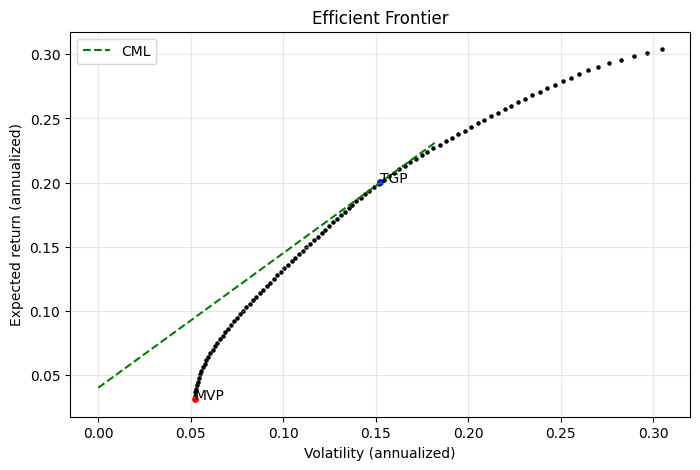

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
for w in frontier:
    media = w@mu
    vol = np.sqrt(w@Sigma@w)
    ax.scatter(vol, media, s=5, color="black")

mvp_mu = MVP@mu
mvp_vol = np.sqrt(MVP@Sigma@MVP)
ax.scatter(mvp_vol, mvp_mu, s=15, color="red")
ax.annotate("MVP", xy=(mvp_vol, mvp_mu))

tg_mu = TgP@mu
tg_vol = np.sqrt(TgP@Sigma@TgP)
ax.scatter(tg_vol, tg_mu, s=15, color="blue")
ax.annotate("TGP", xy=(tg_vol, tg_mu))

cml_x = np.array([0, tg_vol*1.2]) # Capital Market Line: from rf through the TGP
cml_y = rf + (tg_mu - rf)/tg_vol*cml_x
ax.plot(cml_x, cml_y, color="green", linestyle="--", label="CML")
ax.legend()
ax.grid(True, alpha=0.3)

ax.set_xlabel("Volatility (annualized)")
ax.set_ylabel("Expected return (annualized)")
ax.set_title("Efficient Frontier")
plt.show()

For comparison, this second chart shows each of the **n** selected assets individually in risk–return space, with each name labeled by ticker. Recalling the efficient frontier plotted just above, **the frontier dominates these individual names** — diversification lets the portfolio reach a better risk–return trade-off than any single asset can on its own.

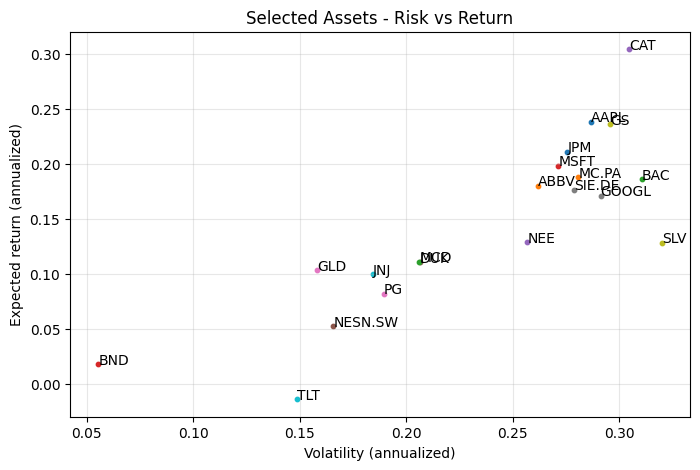

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
for ticker in rend.columns:
    ax.scatter(np.sqrt(Sigma[ticker].loc[ticker]), mu[ticker], s=10)
    ax.annotate(ticker, xy=(np.sqrt(Sigma[ticker].loc[ticker]), mu[ticker]))

ax.set_xlabel("Volatility (annualized)")
ax.set_ylabel("Expected return (annualized)")
ax.set_title("Selected Assets - Risk vs Return")
ax.grid(True, alpha=0.3)
plt.show()

## 6. Output

Finally, we export the **Tangency Portfolio weights** to `TgP_weights.csv`. In the full pipeline (`e_main.py`), this file is written directly into the VaR–ES and Factor Model project folders, where it is consumed as the portfolio definition for risk estimation and factor attribution. Here we save it locally alongside this notebook.

In [19]:
pd.Series(TgP, index=rend.columns).to_csv("TgP_weights.csv")

## 7. Conclusions & limitations

The tangency portfolio produced here maximises the historical Sharpe ratio over the estimation window, but several caveats apply to any MVO implementation.

- **Estimation error on $\mu$.** Expected returns are notoriously hard to estimate; small errors in $\mu$ are amplified by the optimizer into large weight swings. In practice this is addressed via shrinkage estimators (Black–Litterman, Ledoit–Wolf) or robust optimization.
- **In-sample analysis.** All statistics — means, covariances and the resulting portfolio — are computed on the same historical window used for screening. There is no out-of-sample validation, so reported Sharpe ratios are upward-biased.
- **Long-only constraint.** Weights are bounded to $[0, 1]$, ruling out short positions. Relaxing this constraint (with an appropriate risk limit) would expand the feasible set and push the frontier further left.
- **No transaction costs.** Rebalancing to the TGP weights in practice incurs bid–ask spreads and market impact; these are not modelled here.
- **Static allocation.** The model produces a single-period optimal portfolio. A production system would re-estimate and rebalance periodically, introducing turnover and tracking-error considerations.